# Chapter 9 - Bias Variance Trade-off

In the previous chapter, we used Linear Regression to build a simple predictive model. In this chapter, we study an important question: how simple or complex should a model be?

We will use the study-hours dataset to understand Polynomial Regression, Overfitting, Underfitting, Bias, Variance, and the Bias-Variance Tradeoff.

## Step 1 - Import Required Libraries

Firstly, we import the libraries required for data handling, plotting, model building, model evaluation, and polynomial feature creation.

In [1]:
# import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# fixed random state keeps train-test split and demonstrations reproducible
RANDOM_STATE = 42
plt.style.use("default")

## Step 2 - Load and Inspect the Study Dataset

We use a simple dataset where study hours are used to predict marks.

In [2]:
# load the study dataset from the chapter repository
study_data_url = "https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch09/study.csv"

df = pd.read_csv(study_data_url)

print("Dataset shape:", df.shape)
print("First five rows:")
print(df.head())

Dataset shape: (100, 2)
First five rows:
   study_hours      marks
0     1.000000  33.986857
1     1.090909  33.603968
2     1.181818  38.855217
3     1.272727  44.414433
4     1.363636  39.393965


The first inspection tells us that the dataset has one input column, `study_hours`, and one output column, `marks`.

Before building any model, we should check whether the dataset has missing values or unexpected columns.

In [3]:
# check the column names and missing values before model building
print("Columns in the dataset:")
print(df.columns.tolist())

print("\nMissing values in each column:")
print(df.isnull().sum())

Columns in the dataset:
['study_hours', 'marks']

Missing values in each column:
study_hours    0
marks          0
dtype: int64


The above check confirms that both required columns are available and there are no missing values to handle before modelling.

## Step 3 - Visualize the Original Relationship

Now we plot study hours against marks. This is important because the shape of the data tells us whether a straight-line model is enough or not.

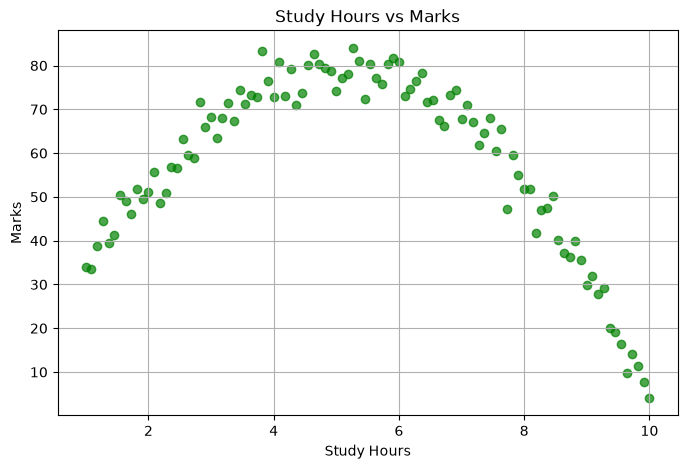

In [4]:
# scatter plot to understand relationship between study hours and marks
plt.figure(figsize=(8, 5))
plt.scatter(df["study_hours"], df["marks"], color="green", alpha=0.7)
plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.grid(True)
plt.show()

It is clear from the above figure that marks increase up to a middle range of study hours and then start decreasing. 

So the relationship is curved, not perfectly linear.

## Step 4 - Build a Linear Regression Baseline

We first train a simple Linear Regression model. This gives us a baseline so that we can later compare it with Polynomial Regression.

In [5]:
# features column
X = df[["study_hours"]]

# target column
y = df["marks"]

# split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print("\nPreview of training features:")
print(X_train.head())

Training rows: 80
Testing rows: 20

Preview of training features:
    study_hours
55     6.000000
88     9.000000
26     3.363636
42     4.818182
69     7.272727


The model will learn from the training data and will be evaluated on the testing data. This helps us judge how well the model works on unseen examples.

In [6]:
# create and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# predict marks for the test set
y_pred_linear = linear_model.predict(X_test)

# calculate Mean Squared Error for the Linear Regression model
mse_linear = mean_squared_error(y_test, y_pred_linear)

print(f"Linear Regression MSE (on test set): {mse_linear:.2f}")
print(f"Intercept: {linear_model.intercept_:.2f}")
print(f"Slope for study_hours: {linear_model.coef_[0]:.2f}")

Linear Regression MSE (on test set): 305.47
Intercept: 77.14
Slope for study_hours: -3.46


The MSE value is the average squared prediction error. 

A large MSE tells us that the straight-line model is not capturing the curved pattern very well.

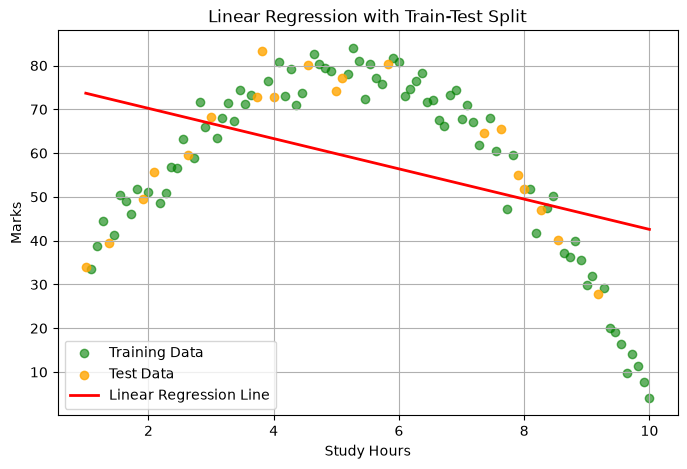

In [7]:
# plot the linear regression line over training and testing points
X_full = pd.DataFrame({
    "study_hours": np.linspace(df["study_hours"].min(), df["study_hours"].max(), 200)
})
y_full_pred_linear = linear_model.predict(X_full)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color="green", label="Training Data", alpha=0.6)
plt.scatter(X_test, y_test, color="orange", label="Test Data", alpha=0.8)
plt.plot(X_full, y_full_pred_linear, color="red", linewidth=2, label="Linear Regression Line")
plt.title("Linear Regression with Train-Test Split")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.legend()
plt.grid(True)
plt.show()

The above figure shows that the line cuts through the dataset, but it misses the peak around the middle. This is a sign that the model is too simple for this data.

## Step 5 - Convert the Input into Polynomial Features

Polynomial Regression helps us model curved relationships. It does this by creating extra features such as squared terms from the original input feature.

In [8]:
# before polynomial transformation, there is only one input feature
print("Before polynomial transformation:")
print(X_train.head())

Before polynomial transformation:
    study_hours
55     6.000000
88     9.000000
26     3.363636
42     4.818182
69     7.272727


Firstly, we look at the feature before transformation. At this point, the model only knows the raw `study_hours` value.

In [9]:
# create degree-2 polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

# fit_transform is used on training data
X_train_poly = poly.fit_transform(X_train)

# transform is used on test data, so we do not learn anything from the test set
X_test_poly = poly.transform(X_test)

poly_feature_names = poly.get_feature_names_out(["study_hours"])
X_train_poly_preview = pd.DataFrame(X_train_poly, columns=poly_feature_names, index=X_train.index)

print("After polynomial transformation:")
print(X_train_poly_preview.head())

After polynomial transformation:
    study_hours  study_hours^2
55     6.000000      36.000000
88     9.000000      81.000000
26     3.363636      11.314050
42     4.818182      23.214876
69     7.272727      52.892562


After transformation, the model gets both `study_hours` and `study_hours^2`. This extra squared feature allows the regression model to fit a curve.

## Step 6 - Train Polynomial Regression

Now we train Linear Regression again, but this time on the polynomial features. The algorithm is still Linear Regression, but the input representation is richer.

In [10]:
# train Linear Regression on polynomial features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# predict on polynomial test features
y_pred_poly = poly_model.predict(X_test_poly)

# calculate Mean Squared Error for Polynomial Regression
mse_poly = mean_squared_error(y_test, y_pred_poly)

In [11]:
# compare MSE for both models
print(f"Linear Regression MSE (degree 1): {mse_linear:.2f}")
print(f"Polynomial Regression MSE (degree 2): {mse_poly:.2f}")

Linear Regression MSE (degree 1): 305.47
Polynomial Regression MSE (degree 2): 9.91


The comparison shows why Polynomial Regression is useful here. 

The degree-2 model gives the model enough flexibility to capture the curved pattern.
Due to this, it is able to fit tin he curved datset, in a much better way.
That's why test error becomes much smaller for the polynomial regression model.

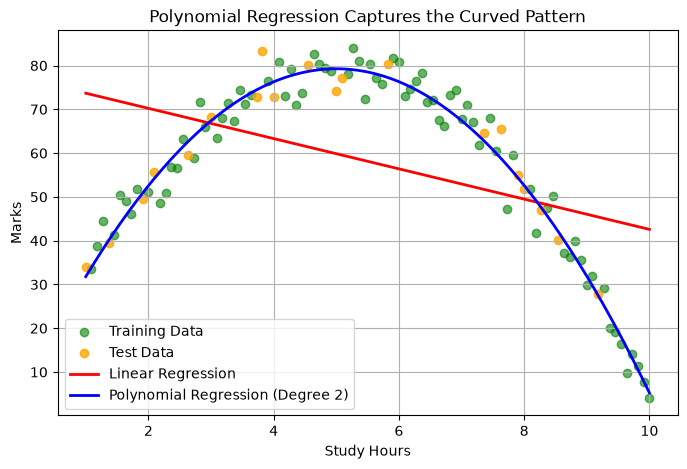

In [12]:
# plot Linear Regression and Polynomial Regression together
X_full_poly = poly.transform(X_full)
y_full_pred_poly = poly_model.predict(X_full_poly)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color="green", label="Training Data", alpha=0.6)
plt.scatter(X_test, y_test, color="orange", label="Test Data", alpha=0.8)
plt.plot(X_full, y_full_pred_linear, color="red", linewidth=2, label="Linear Regression")
plt.plot(X_full, y_full_pred_poly, color="blue", linewidth=2, label="Polynomial Regression (Degree 2)")
plt.title("Polynomial Regression Captures the Curved Pattern")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.legend()
plt.grid(True)
plt.show()

Clearly, the blue curve line of polynomial model follows the actual shape of the data much better than the red straight line of simple linear regression model.

## Step 7 - Understand Overfitting

If we keep increasing the polynomial degree, the model becomes more flexible. Some flexibility is useful, but too much flexibility can make the model follow noise in the training data.

In [13]:
# compare models with different polynomial degrees
degrees = [1, 2, 5, 15, 20]
results = []
trained_models = {}

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append({
        "degree": degree,
        "train_mse": mean_squared_error(y_train, train_pred),
        "test_mse": mean_squared_error(y_test, test_pred),
    })
    trained_models[degree] = model

results_df = pd.DataFrame(results)
print(results_df)

   degree   train_mse    test_mse
0       1  358.609945  305.473449
1       2   13.764125    9.914129
2       5   12.782070   10.821307
3      15  118.296634  166.304856
4      20  116.736161  164.593197


The above table lets us compare training error and testing error for polynomial models of various degrees.

Overfitting usually appears when training error is very low but testing error becomes much higher.

Clearly, the degree of 15 and 20 - is resulting in overfitted models.

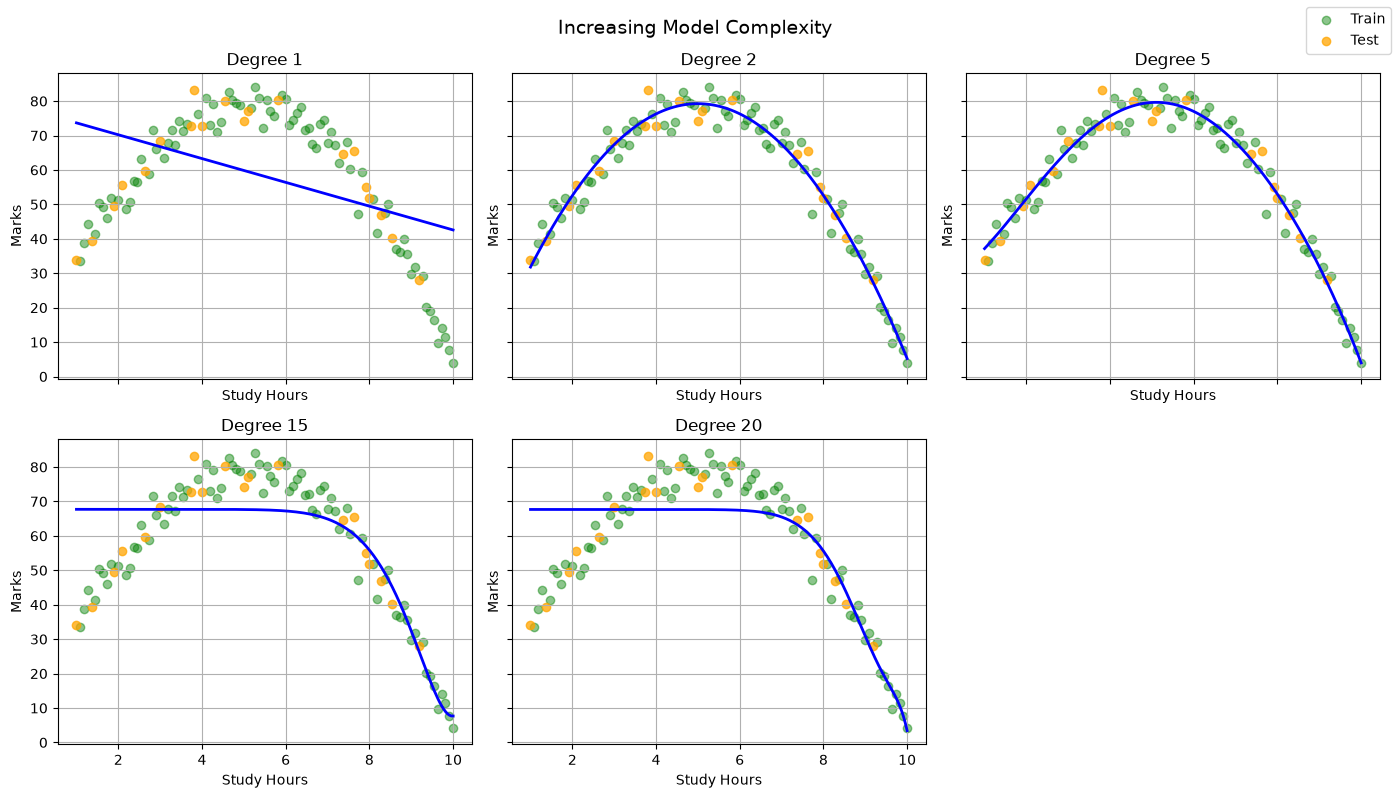

In [14]:
# visualize how the fitted curve changes as degree increases
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, degree in zip(axes, degrees):
    y_curve = trained_models[degree].predict(X_full)
    ax.scatter(X_train, y_train, color="green", alpha=0.45, label="Train")
    ax.scatter(X_test, y_test, color="orange", alpha=0.75, label="Test")
    ax.plot(X_full, y_curve, color="blue", linewidth=2)
    ax.set_title(f"Degree {degree}")
    ax.set_xlabel("Study Hours")
    ax.set_ylabel("Marks")
    ax.grid(True)

axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Increasing Model Complexity", fontsize=14)
plt.tight_layout()
plt.show()

It is clear that high-degree curves become more wavy and less reliable, as and when degree is increased.

In [15]:
# calculate the gap between test error and training error
results_df["test_minus_train_mse"] = results_df["test_mse"] - results_df["train_mse"]

print("Training and testing error comparison:")
print(results_df.sort_values("degree"))

Training and testing error comparison:
   degree   train_mse    test_mse  test_minus_train_mse
0       1  358.609945  305.473449            -53.136496
1       2   13.764125    9.914129             -3.849997
2       5   12.782070   10.821307             -1.960763
3      15  118.296634  166.304856             48.008222
4      20  116.736161  164.593197             47.857036


The `test_minus_train_mse` column helps us detect overfitting.

A large positive gap means the model is doing much better on training data than on unseen test data, i.e., the model is overfitting the training data.

## Step 8 - Understand Underfitting

Underfitting happens when the model is too simple to learn the actual pattern. In this dataset, the degree-1 model underfits because it can only draw a straight line.

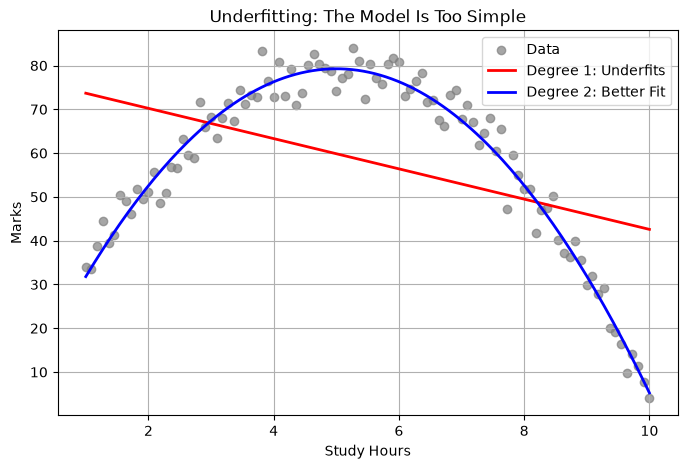

In [16]:
# compare an underfit model with a better degree-2 model
underfit_model = trained_models[1]
balanced_model = trained_models[2]

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="gray", alpha=0.7, label="Data")
plt.plot(X_full, underfit_model.predict(X_full), color="red", linewidth=2, label="Degree 1: Underfits")
plt.plot(X_full, balanced_model.predict(X_full), color="blue", linewidth=2, label="Degree 2: Better Fit")
plt.title("Underfitting: The Model Is Too Simple")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.legend()
plt.grid(True)
plt.show()

The red line of simple linear regression model is clearly not able to learn the true nature of the dataset.

The blue curve of polynomial model is flexible enough to represent the underlying curved pattern of the dataset.

## Step 9 - Understand Bias and Variance

Bias means error caused by overly simple assumptions. 

Variance means the model is too sensitive to small changes in training data. 

We will use a sinusoidal function to visualize both ideas.

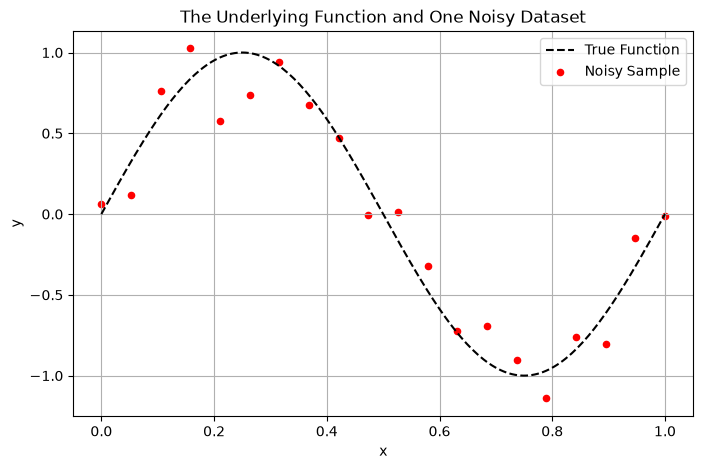

In [17]:
# Define the true target function (sine wave) for the bias-variance trade-off demo
def true_function(x):
    return np.sin(2 * np.pi * x)


# Function to simulate data generation by adding random Gaussian noise to the true curve
def generate_dataset(n_samples=20, noise=0.2, random_seed=None):
    """Generate one noisy sample from the same underlying curve."""
    # Initialize a random number generator for reproducibility
    rng = np.random.default_rng(random_seed)

    # Generate evenly spaced input features between 0 and 1
    X_sample = np.linspace(0, 1, n_samples)

    # Calculate target values using the true function and add normal distribution noise
    y_sample = true_function(X_sample) + rng.normal(0, noise, X_sample.shape)

    # Return X reshaped as a 2D column vector (required by Scikit-Learn) and y as a 1D array
    return X_sample.reshape(-1, 1), y_sample


# Create a dense grid of 200 points to plot the smooth, theoretical true function
X_curve = np.linspace(0, 1, 200).reshape(-1, 1)
y_true_curve = true_function(X_curve).ravel()

# Generate a small, noisy dataset to represent training or testing points
X_example, y_example = generate_dataset(random_seed=RANDOM_STATE)

# --- Visualization Setup ---
plt.figure(figsize=(8, 5))

# Plot the ideal, noise-free underlying relationship as a dashed black line
plt.plot(X_curve, y_true_curve, "k--", label="True Function")

# Plot the generated noisy data points as red dots
plt.scatter(X_example, y_example, color="red", s=20, label="Noisy Sample")

# Add chart metadata for clarity and presentation
plt.title("The Underlying Function and One Noisy Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

# Render the plot on screen
plt.show()


The dashed curve is the true relationship.

The red points are noisy samples from that curve. 

A good model should learn the broad curve without chasing every noisy point.

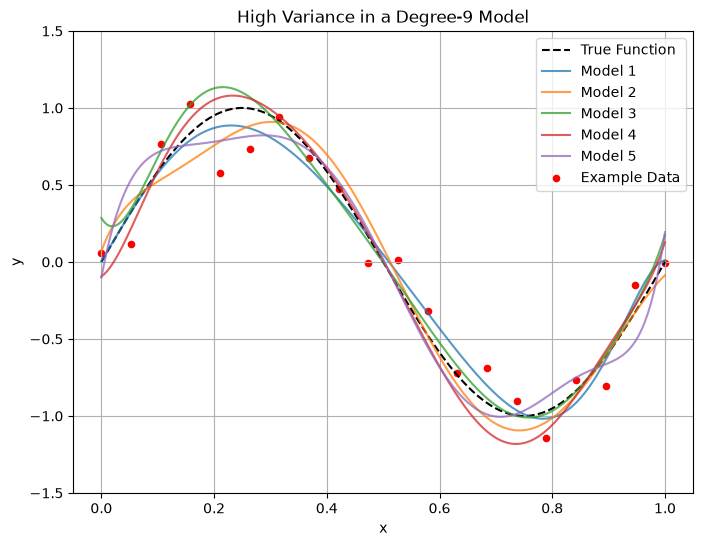

In [18]:
# Configure a complex, high-degree model to demonstrate high variance and overfitting
high_variance_degree = 9

# Number of different simulated training sets to generate
n_datasets = 5

# --- Visualization Setup ---
plt.figure(figsize=(8, 6))

# Plot the ideal, noise-free true relationship as the baseline reference
plt.plot(X_curve, y_true_curve, "k--", label="True Function")

# Loop to fit and plot a separate high-degree model for each independent dataset
for i in range(n_datasets):
    # Generate a unique, noisy dataset by changing the random seed for each iteration
    X_sample, y_sample = generate_dataset(random_seed=RANDOM_STATE + i)

    # Build a pipeline that transforms features to degree-9 polynomials and fits a linear regression
    model = make_pipeline(
        PolynomialFeatures(high_variance_degree, include_bias=False),
        LinearRegression(),
    )

    # Train the complex model on the current noisy dataset
    model.fit(X_sample, y_sample)

    # Predict over the entire curve range and plot with partial transparency to see overlapping lines
    plt.plot(
        X_curve, model.predict(X_curve), alpha=0.75, label=f"Model {i + 1}"
    )

# Superimpose the initial example data points for context
plt.scatter(X_example, y_example, color="red", s=20, label="Example Data")
plt.ylim(-1.5, 1.5)
plt.title("High Variance in a Degree-9 Model")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


The degree-9 models are very flexible.

Their curves change a lot across similar datasets, which shows high variance.

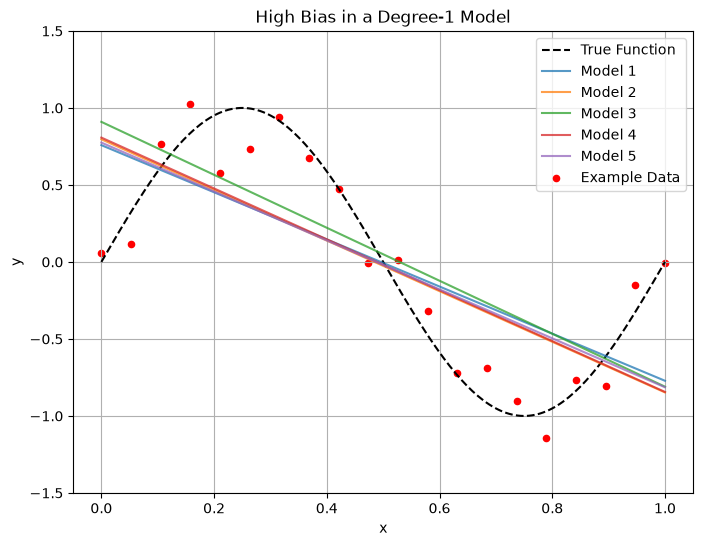

In [19]:
# Configure a simple, low-degree model to demonstrate high bias and underfitting
high_bias_degree = 1

# --- Visualization Setup ---
plt.figure(figsize=(8, 6))

# Plot the ideal, noise-free true relationship as the baseline reference
plt.plot(X_curve, y_true_curve, "k--", label="True Function")

# Loop to fit and plot a separate linear model for each independent dataset
for i in range(n_datasets):
    # Generate a unique, noisy dataset by changing the random seed for each iteration
    X_sample, y_sample = generate_dataset(random_seed=RANDOM_STATE + i)

    # Build a pipeline that fits a straight line (degree-1 polynomial features)
    model = make_pipeline(
        PolynomialFeatures(high_bias_degree, include_bias=False),
        LinearRegression(),
    )

    # Train the simple model on the current noisy dataset
    model.fit(X_sample, y_sample)

    # Predict over the entire curve range to show how stable (but wrong) the straight lines are
    plt.plot(
        X_curve, model.predict(X_curve), alpha=0.75, label=f"Model {i + 1}"
    )

# Superimpose the initial example data points for context
plt.scatter(X_example, y_example, color="red", s=20, label="Example Data")
plt.ylim(-1.5, 1.5)
plt.title("High Bias in a Degree-1 Model")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


The degree-1 models are highly stable across different datasets, but they are too rigid to capture the nonlinear sine wave. 

This systematic underfitting is a clear example of high bias.  

## Step 10 - Study the Bias-Variance Tradeoff

The tradeoff is about choosing a model that is neither too simple nor too complex. 

We want low test error, not just low training error.

In [20]:
# summarize the tradeoff using model degree and MSE values
tradeoff_table = results_df[["degree", "train_mse", "test_mse", "test_minus_train_mse"]].copy()
tradeoff_table["train_mse"] = tradeoff_table["train_mse"].round(2)
tradeoff_table["test_mse"] = tradeoff_table["test_mse"].round(2)
tradeoff_table["test_minus_train_mse"] = tradeoff_table["test_minus_train_mse"].round(2)

print(tradeoff_table)

   degree  train_mse  test_mse  test_minus_train_mse
0       1     358.61    305.47                -53.14
1       2      13.76      9.91                 -3.85
2       5      12.78     10.82                 -1.96
3      15     118.30    166.30                 48.01
4      20     116.74    164.59                 47.86


A balanced model is usually found near the point where
- testing error is low and 
- the gap between training and testing error is not too large.

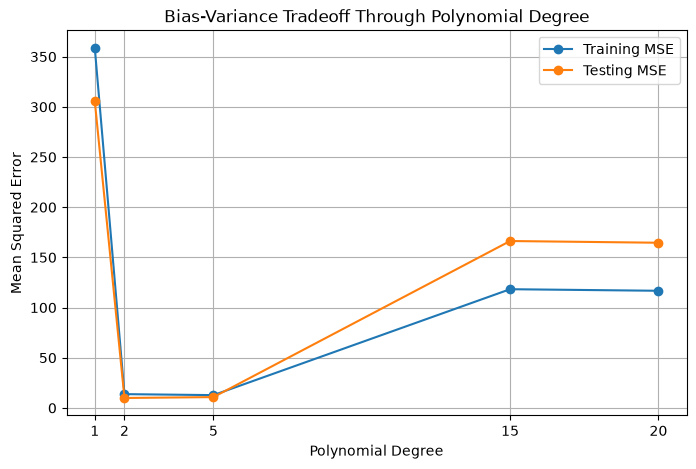

In [21]:
# plot training and testing error against model complexity
plt.figure(figsize=(8, 5))
plt.plot(results_df["degree"], results_df["train_mse"], marker="o", label="Training MSE")
plt.plot(results_df["degree"], results_df["test_mse"], marker="o", label="Testing MSE")
plt.title("Bias-Variance Tradeoff Through Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.xticks(degrees)
plt.legend()
plt.grid(True)
plt.show()

The training error generally decreases as model complexity increases.

However, the testing error determines whether the model generalizes well to unseen data. 

As shown in the figure above, the optimal balance between training and testing error is achieved when the polynomial degree is between 2 and 5.

## Chapter Recap

In this chapter, we learned the following ideas:

- Linear Regression is a useful baseline, but it can underfit curved data.
- Polynomial Regression creates higher-degree input features so a linear model can fit curved patterns.
- Underfitting happens when the model is too simple and performs poorly even on training data.
- Overfitting happens when the model is too complex and learns noise from the training data.
- Bias is error from overly simple assumptions.
- Variance is sensitivity to small changes in training data.
- The best model is usually a balanced model that performs well on unseen test data.